In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

AttributeError: partially initialized module 'pandas' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

In [ ]:
df = sns.load_dataset('titanic')

df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# handle missing values 
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(712, 8)

In [ ]:
# Create and Train the Model
tree_model = DecisionTreeClassifier(random_state=42) # Koi max_depth nahi di (Fully grown)
tree_model.fit(X_train, y_train)

# Predictions
y_pred_train = tree_model.predict(X_train)
y_pred_test = tree_model.predict(X_test)

# Check Accuracy
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

Training Accuracy: 0.9789
Testing Accuracy: 0.7821


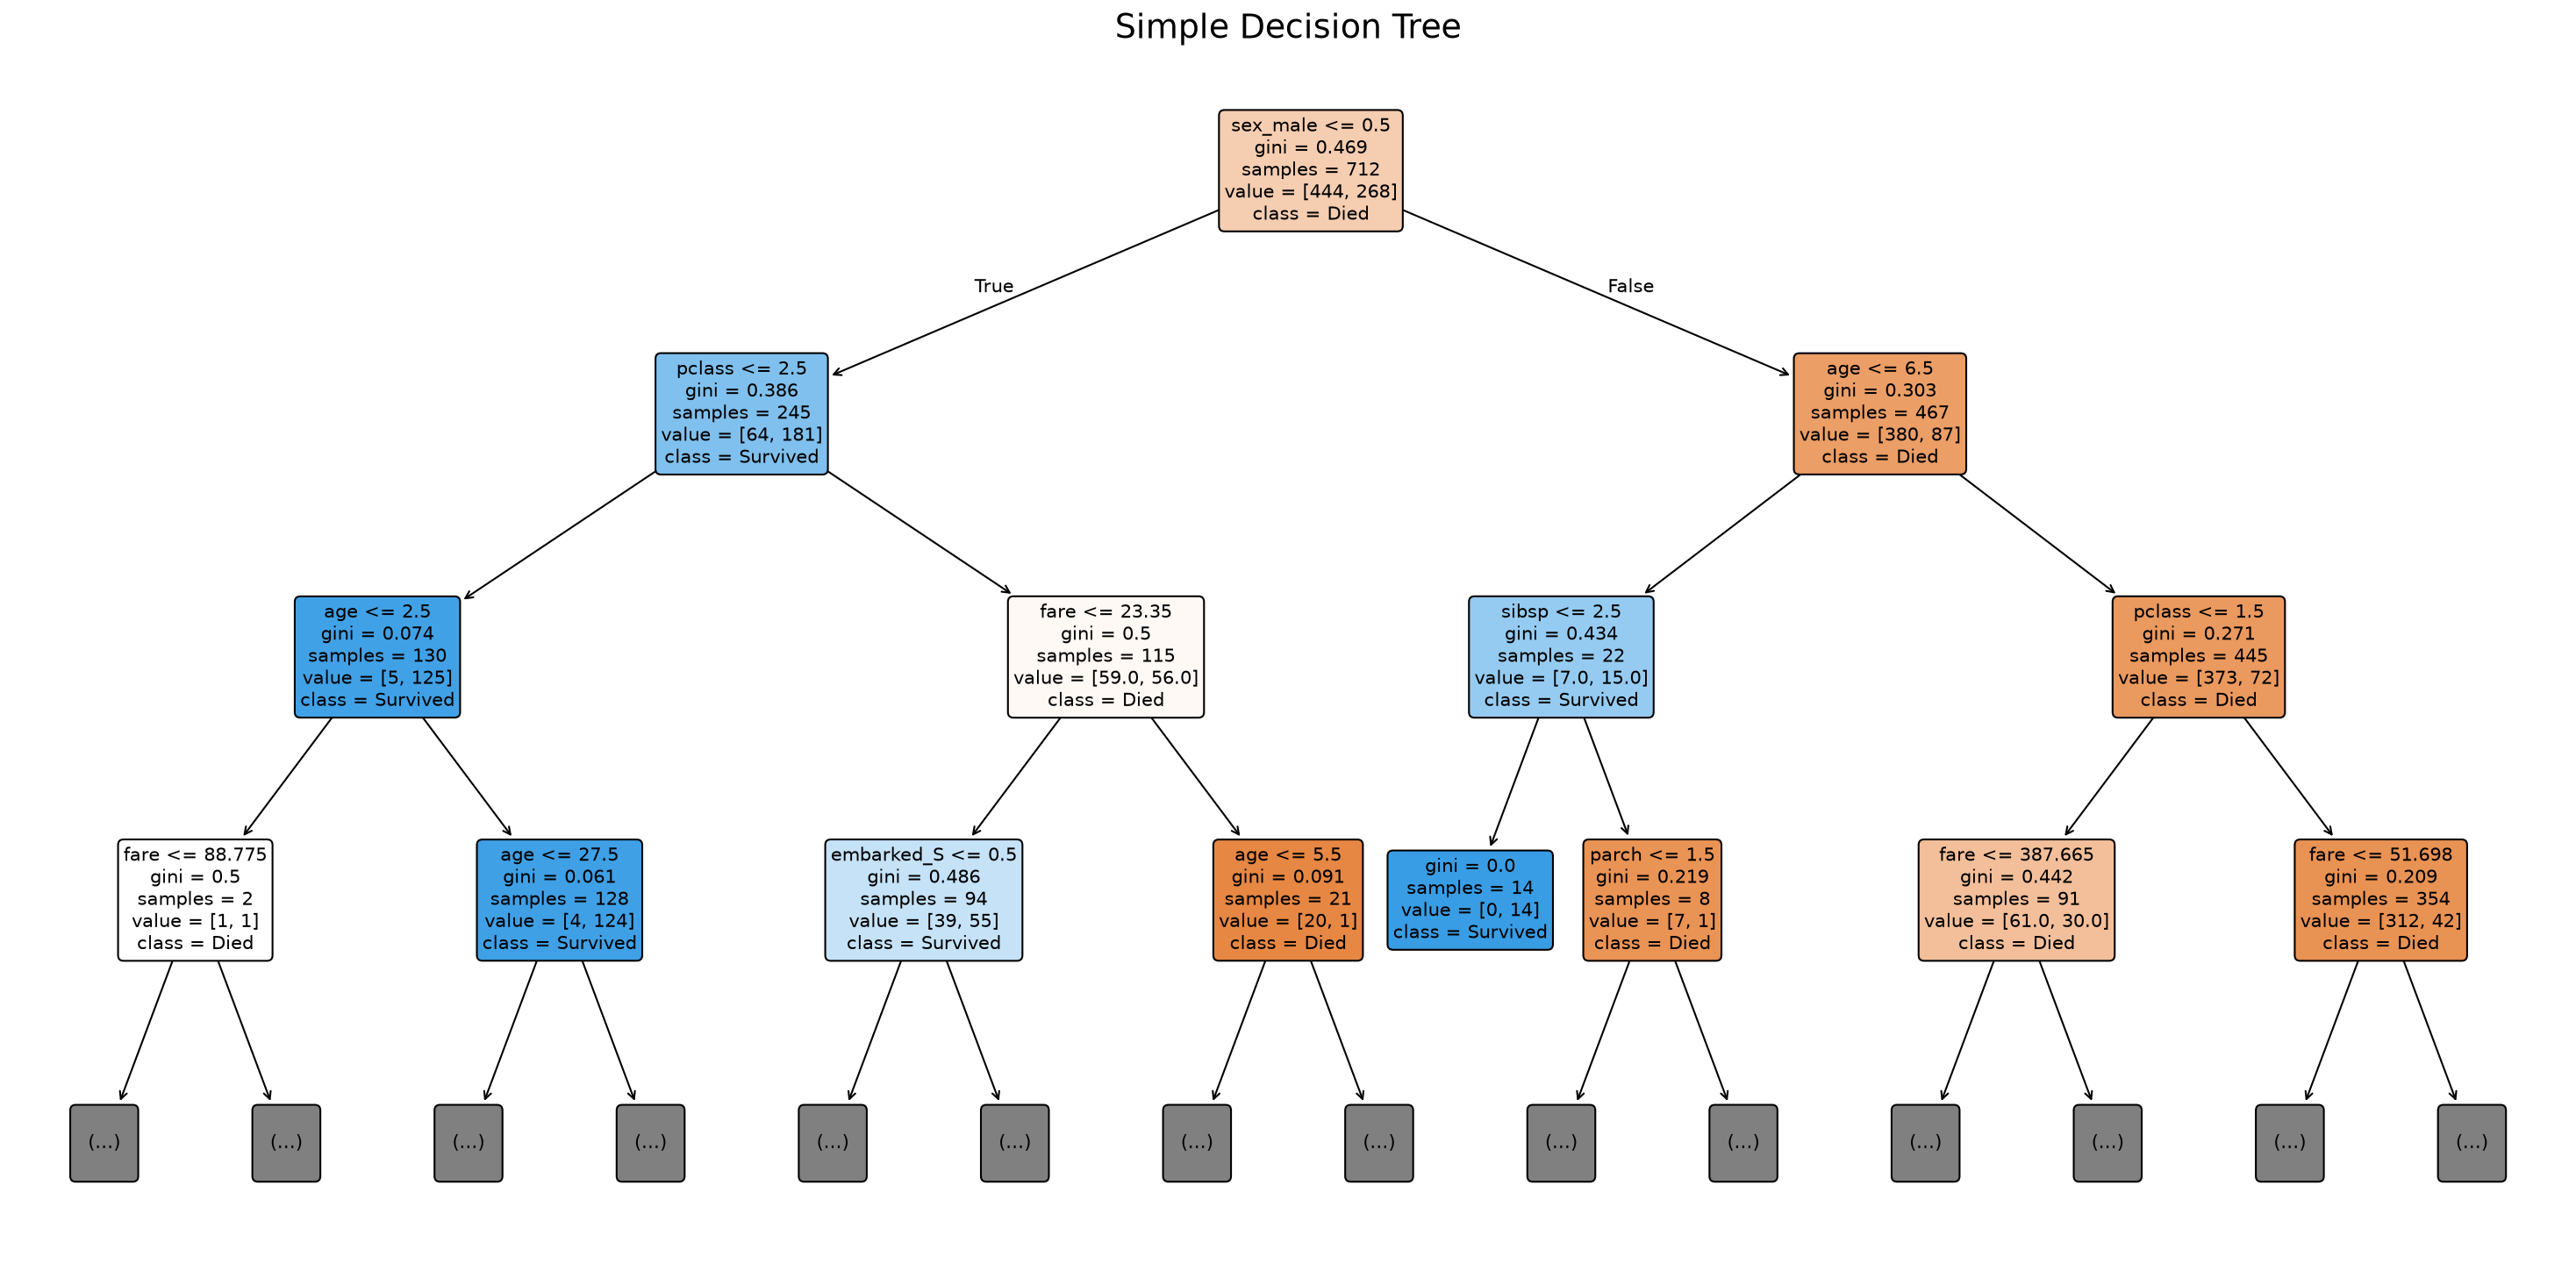

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12), dpi=150) 


plot_tree(tree_model, 
          feature_names=X.columns,    
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          max_depth=3,               
          fontsize=10)                

plt.title("Simple Decision Tree", fontsize=18)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=False
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_)
print("testing accuracy: ", accuracy_score(y_test, y_pred))

KeyboardInterrupt: 